In [2]:
%pip install -r ../requirements.txt

  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/63/13/f9a8046535cb21deae82f8d03de9617e08882d274fad2539630761888228/numpy-2.4.6-cp311-cp311-macosx_14_0_x86_64.whl.metadata
  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/ec/e6/cef1cf3557f0c54954198554a10016b6a03b2ec9e22a4e1df734936bd99c/scipy-1.17.1-cp311-cp311-macosx_14_0_x86_64.whl.metadata
  Using cached scipy-1.17.1-cp311-cp311-macosx_14_0_x86_64.whl.metadata (62 kB)
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/c0/a9/a7fc5a63c427aeb9a4b99d6a0449f891be0952d3aee2b85229099f7b9f54/matplotlib-3.11.2-cp311-cp311-macosx_10_12_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.0 MB/s eta 0:00:00
  Obtaining dependency information for jupyter from https://files.pythonhosted.org/packages/38/64/285f20a31679bf547b75602702f7800e74dbabae36ef324f716c02804753/jupyter-1.1.1-py2.py3-none-an

In [3]:
import numpy as np
import matplotlib.pyplot as plt
print("ready")

Matplotlib is building the font cache; this may take a moment.


ready


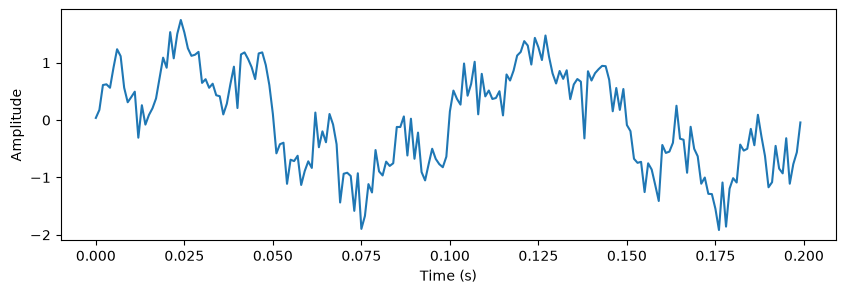

In [4]:
fs = 1000
duration = 2
t = np.arange(0, duration, 1/fs)

signal = np.sin(2 * np.pi * 10 * t)
mains = 0.5 * np.sin(2 * np.pi * 50 * t)
rng = np.random.default_rng(0)
noise = rng.normal(0, 0.3, size=len(t))

x = signal + mains + noise

plt.figure(figsize=(10, 3))
plt.plot(t[:200], x[:200])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

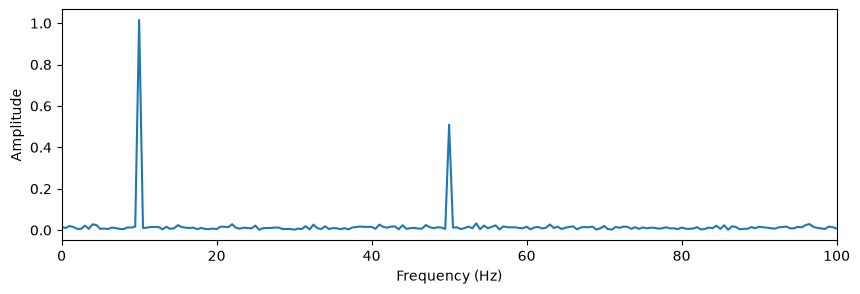

In [5]:
X = np.fft.rfft(x)                         # the FFT itself
freqs = np.fft.rfftfreq(len(x), 1/fs)      # which frequency each value belongs to
amp = 2 * np.abs(X) / len(x)               # convert to amplitude

plt.figure(figsize=(10, 3))
plt.plot(freqs, amp)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.xlim(0, 100)
plt.show()

In [6]:
print(freqs[np.argmax(amp)])

10.0


In [8]:
print(freqs[1] - freqs[0])

0.5


In [9]:
from scipy.signal import butter, filtfilt

b, a = butter(4, 30, btype="low", fs=fs)   # design a low-pass filter at 30 Hz
x_filt = filtfilt(b, a, x)                 # apply it

In [10]:
print(x_filt[:5])

[-0.04045895  0.01168721  0.06606048  0.12184032  0.1782684 ]


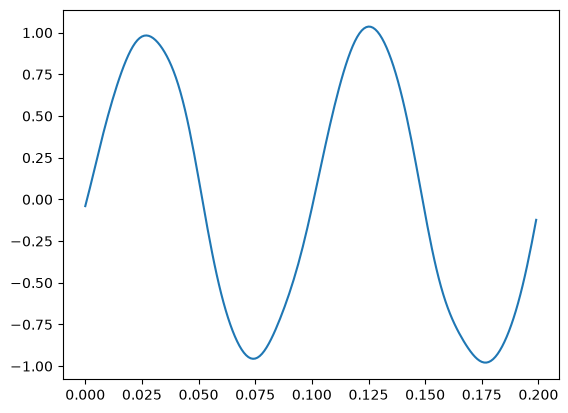

In [11]:
plt.plot(t[:200], x_filt[:200])

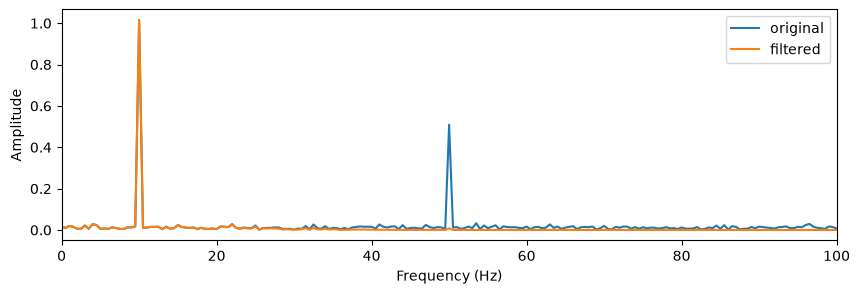

In [14]:
X_filt = np.fft.rfft(x_filt)
freqs = np.fft.rfftfreq(len(x_filt), 1/fs)
amp_filt = 2 * np.abs(X_filt) / len(x_filt)

plt.figure(figsize=(10, 3))
plt.plot(freqs, amp, label="original")
plt.plot(freqs, amp_filt, label="filtered")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.xlim(0, 100)
plt.legend()
plt.savefig("../figures/filter_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure: Effect of a 30 Hz low-pass filter on the amplitude spectrum.**
The original signal (blue) contains a 10 Hz sine (amplitude 1), 50 Hz mains interference (amplitude 0.5) and Gaussian noise. A 4th-order Butterworth low-pass filter at 30 Hz, applied forwards and backwards with `filtfilt`, removed the 50 Hz peak and the noise above 30 Hz (orange). The 10 Hz peak kept its full amplitude. Noise below 30 Hz remained, because a filter cannot separate noise from signal at the same frequencies.